In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/envs/latr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MetaMathQA Analysis

In [2]:
# Load the full training split (≈395 K rows). Remove streaming=True if you prefer an in-memory Dataset.
ds = load_dataset("meta-math/MetaMathQA", split="train")
ds = ds.select(range(150_000))

# Qwen 2.5-0.5 B tokenizer (trust_remote_code=True is required for custom fast-tokenizer code)
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B", trust_remote_code=True)

In [3]:
# tokenize the responses
lens = []

for ex in tqdm(ds, desc="Tokenising MetaMathQA"):
    text = (ex.get("response", "")).strip()
    lens.append(len(tok.encode(text)))

lens = np.asarray(lens, dtype=np.uint32)

Tokenising MetaMathQA: 100%|██████████| 150000/150000 [00:44<00:00, 3347.93it/s]


In [4]:
print(f"Examples analysed : {lens.size:_}")
print(f"Min tokens        : {lens.min():_}")
print(f"Max tokens        : {lens.max():_}")
print(f"Average tokens    : {lens.mean():,.2f}")
print(f"Median tokens     : {np.median(lens):_}")

Examples analysed : 150_000
Min tokens        : 4
Max tokens        : 2_450
Average tokens    : 176.42
Median tokens     : 150.0


In [5]:
# Print percentiles of the token length distribution
percentiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.80, 0.85, 0.90, 0.99]
vals = np.quantile(lens, percentiles)

print("Token-length percentiles (Qwen 2.5-0.5 B tokenizer)")
for p, v in zip(percentiles, vals):
    print(f" {p:>5.2%}  →  {int(v):_} tokens")


Token-length percentiles (Qwen 2.5-0.5 B tokenizer)
 1.00%  →  51 tokens
 10.00%  →  81 tokens
 25.00%  →  107 tokens
 50.00%  →  150 tokens
 75.00%  →  218 tokens
 80.00%  →  239 tokens
 85.00%  →  264 tokens
 90.00%  →  299 tokens
 99.00%  →  556 tokens


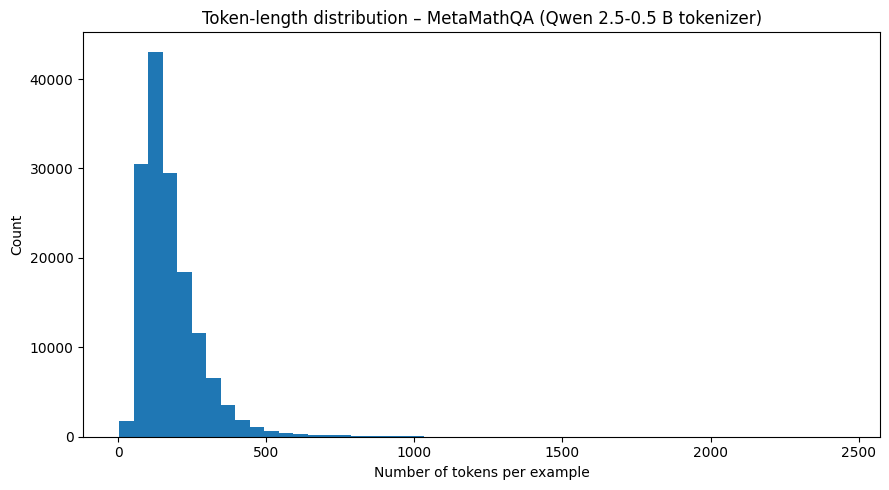

In [6]:
plt.figure(figsize=(9,5))
# 50 equal-width bins give a clear overview; adjust as you like.
plt.hist(lens, bins=50)
plt.title("Token-length distribution – MetaMathQA (Qwen 2.5-0.5 B tokenizer)")
plt.xlabel("Number of tokens per example")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
# check the response with the highest number of tokens
# ─── 6️⃣ Show the 5 longest examples ───────────────────────────────────────────
from heapq import nlargest

top5 = []

for ex in tqdm(ds, desc="Collecting longest examples"):
    text   = ex.get("response", "")
    length = len(tok.encode(text))

    top5.append((length, ex))           # push current example
    if len(top5) > 5:                   # keep only the 5 largest
        top5 = nlargest(5, top5, key=lambda x: x[0])

# Sort so rank-1 is the absolute longest
top5 = sorted(top5, key=lambda x: x[0], reverse=True)

for rank, (length, ex) in enumerate(top5, 1):
    print(f"\n====== TOP {rank} – {length} tokens ======\n")
    print("■ Question:\n", ex.get("query", "(none)"))
    print("\n■ Answer:\n",   ex.get("response",   "(none)"))



====== TOP 1 – 2450 tokens ======

■ Question:
 The equations $75x^4 + ax^3 + bx^2 + cx + 12 = 0$ and $12x^5 + dx^4 + ex^3 + fx^2 + gx + 75 = 0$ have a common rational root $k$, which is negative and not an integer. What is the value of $k$?

■ Answer:
 By the Rational Root Theorem, $k$ must be a divisor of both 12 and 75.
Since $k$ is negative and not an integer, the only possible values for $k$ are $-\frac{1}{2}$ and $-\frac{1}{3}$.
We can substitute these values into the equations and check if they satisfy both equations.
For $k=-\frac{1}{2}$, the first equation becomes $75\left(-\frac{1}{2}\right)^4 + a\left(-\frac{1}{2}\right)^3 + b\left(-\frac{1}{2}\right)^2 + c\left(-\frac{1}{2}\right) + 12 = 0$, which simplifies to $-\frac{75}{16}+\frac{a}{8}-\frac{b}{4}+\frac{c}{2}+12=0$.
Similarly, for $k=-\frac{1}{3}$, the first equation becomes $75\left(-\frac{1}{3}\right)^4 + a\left(-\frac{1}{3}\right)^3 + b\left(-\frac{1}{3}\right)^2 + c\left(-\frac{1}{3}\right) + 12 = 0$, which simplifi

## whynlp/gsm8k-aug-nl Analysis

In [2]:
# Load the full training split (≈395 K rows). Remove streaming=True if you prefer an in-memory Dataset.
ds = load_dataset("whynlp/gsm8k-aug-nl", split="train")
# ds = ds.select(range(150_000))

# Qwen 2.5-0.5 B tokenizer (trust_remote_code=True is required for custom fast-tokenizer code)
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B", trust_remote_code=True)

Generating test split: 100%|██████████| 1319/1319 [00:00<00:00, 661519.43 examples/s]


In [16]:
def _map_func(example, tokenizer):

    answer_list = example["steps"]
    answer = " ".join(example["steps"])
    num_steps = len(answer_list)

    return {"num_steps": num_steps, "answer_list": answer_list}

In [17]:
ds = ds.map(_map_func, fn_kwargs={"tokenizer": tok})

Map: 100%|██████████| 385620/385620 [00:11<00:00, 33020.55 examples/s]


In [18]:
ds

Dataset({
    features: ['question', 'steps', 'answer', 'num_steps', 'answer_list'],
    num_rows: 385620
})

In [19]:
ds['steps'][0]

['600 x 30/100 = 180 employees were promoted.',
 '600 x 10/100 = 60 employees received a bonus.',
 'So a total of 180+60=240 employees received a promotion or a bonus.',
 'Therefore, 600 - 240 = 360 employees did not get either a promotion or a bonus.']

In [20]:
ds['num_steps'][0]

4

In [23]:
# Statistics
print(f"Mean: {np.mean(ds['num_steps'])}")
print(f"Median: {np.median(ds['num_steps'])}")
print(f"Min: {np.min(ds['num_steps'])}")
print(f"Max: {np.max(ds['num_steps'])}")

Mean: 2.650212644572377
Median: 2.0
Min: 1
Max: 17


In [26]:
# Print percentiles of the token length distribution
percentiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.80, 0.85, 0.90, 0.99]
vals = np.quantile(ds["num_steps"], percentiles)

print("Steps percentiles (Qwen 2.5-0.5 B tokenizer)")
for p, v in zip(percentiles, vals):
    print(f" {p:>5.2%}  →  {int(v):_} tokens")

Steps percentiles (Qwen 2.5-0.5 B tokenizer)
 1.00%  →  1 tokens
 10.00%  →  1 tokens
 25.00%  →  2 tokens
 50.00%  →  2 tokens
 75.00%  →  3 tokens
 80.00%  →  4 tokens
 85.00%  →  4 tokens
 90.00%  →  4 tokens
 99.00%  →  6 tokens


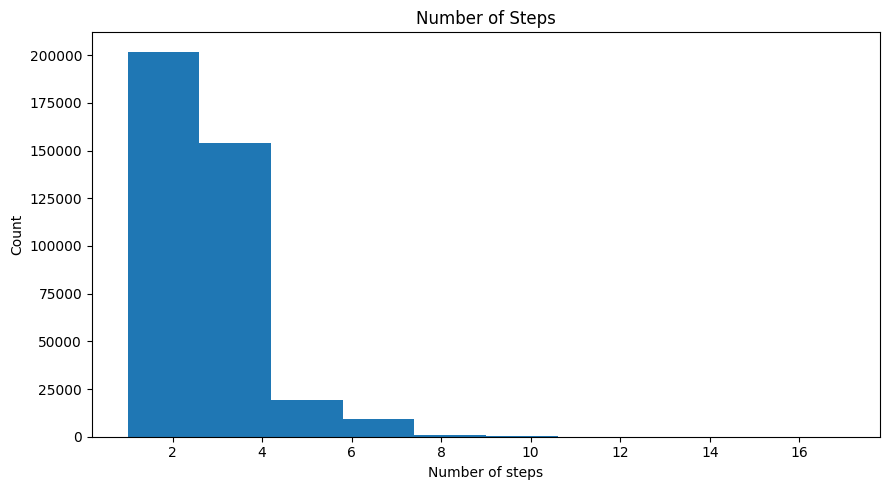

In [24]:
plt.figure(figsize=(9,5))
plt.hist(ds['num_steps'], bins=10)
plt.title("Number of Steps")
plt.xlabel("Number of steps")
plt.ylabel("Count")
plt.tight_layout()
plt.show()